In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset_id = "wikimedia/wikipedia"
configs_file = "config.json"
compression_methods = ["snappy", "gzip", "brotli", "lz4", "zstd"]
config_dict = json.load(open(configs_file, "r"))[dataset_id]['configs']
compress_methods_count = len(config_dict[0]['compress'])
size_dict = {
    "snappy": 0,
    "gzip": 0,
    "brotli": 0,
    "lz4": 0,
    "zstd": 0,
}
compress_size_list = [size_dict.copy() for _ in range(compress_methods_count)]

In [3]:
for config in config_dict:
    # print(f"config name: {config['file']}")
    for compression_method in compression_methods:
        size_dict[compression_method] += config[f'size_{compression_method}']
    for i, compress in enumerate(config['compress']):
        for compression_method in compression_methods:
            compress_size_list[i][compression_method] += compress[f'size_compression_{compression_method}']
    

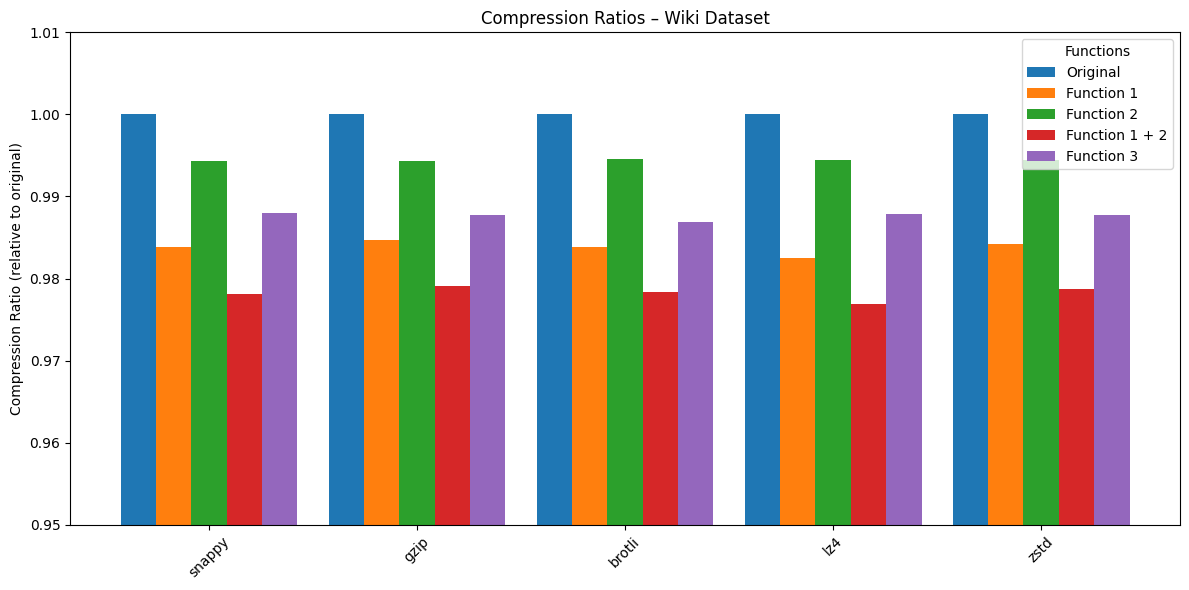

In [4]:
functions = ["Original", "Function 1", "Function 2", "Function 1 + 2", "Function 3"]
# compression_method = "snappy"
values = [size_dict[compression_method]]
# ori = values[0]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

x = np.arange(len(compression_methods))
bar_width = 0.17

plt.figure(figsize=(12, 6))

for f_idx, func in enumerate(functions):
    ratios = []
    for method in compression_methods:
        original = size_dict[method]
        if f_idx == 0:
            ratios.append(1.0)  # Original
        else:
            comp_size = compress_size_list[f_idx - 1][method]
            ratios.append(comp_size / original)
    
    positions = x + (f_idx - (len(functions) / 2)) * bar_width + bar_width / 2
    plt.bar(positions, ratios, bar_width, label=func, color=colors[f_idx])

plt.ylabel("Compression Ratio (relative to original)")
plt.title("Compression Ratios – Wiki Dataset")
plt.xticks(x, compression_methods, rotation=45)
plt.ylim(0.95, 1.01)
plt.legend(title="Functions")
plt.tight_layout()
plt.savefig("plots/compression_ratios_Wiki.png")
plt.show()


In [8]:
dataset_id = "wikimedia/wikipedia"
configs_file = "config.json"
compression_methods = "snappy"
config_dict = json.load(open(configs_file, "r"))[dataset_id]['configs']
compress_functions_count = len(config_dict[0]['compress'])
info_dict = {
    "original_size": 0,
    "compress_size": 0,
    "title_ori": 0,
    "title_com": 0,
    "text_ori": 0,
    "text_com": 0,
    "url_ori": 0,
    "url_com": 0,
}
compress_size_list = [info_dict.copy() for _ in range(compress_functions_count)]

In [9]:
for config in config_dict:
    for i, compress in enumerate(config['compress']):
        compress_size_list[i]["original_size"] += config[f'size_snappy']
        compress_size_list[i]["compress_size"] += compress[f'size_compression_snappy']
        if "title_ori" in compress[f'query_time']:
            compress_size_list[i]["title_ori"] += compress[f'query_time']['title_ori']
            compress_size_list[i]["title_com"] += compress[f'query_time']['title_com']
        if "text_ori" in compress[f'query_time']:
            compress_size_list[i]["text_ori"] += compress[f'query_time']['text_ori']
            compress_size_list[i]["text_com"] += compress[f'query_time']['text_com']
        if "url_ori" in compress[f'query_time']:
            compress_size_list[i]["url_ori"] += compress[f'query_time']['url_ori']
            compress_size_list[i]["url_com"] += compress[f'query_time']['url_com']

print(compress_size_list)

[{'original_size': 5352174653, 'compress_size': 5265844668, 'title_ori': 0, 'title_com': 0, 'text_ori': 0, 'text_com': 0, 'url_ori': 0.853187084197998, 'url_com': 15.678958654403687}, {'original_size': 5352174653, 'compress_size': 5321506933, 'title_ori': 0.9930603504180908, 'title_com': 37.70168399810791, 'text_ori': 55.03193378448486, 'text_com': 65.71483111381531, 'url_ori': 0, 'url_com': 0}, {'original_size': 5352174653, 'compress_size': 5235161994, 'title_ori': 1.0411245822906494, 'title_com': 37.57881164550781, 'text_ori': 54.0577118396759, 'text_com': 64.62722897529602, 'url_ori': 1.2709345817565918, 'url_com': 49.86092710494995}, {'original_size': 5352174653, 'compress_size': 5287887357, 'title_ori': 1.0051743984222412, 'title_com': 29.81672167778015, 'text_ori': 0, 'text_com': 0, 'url_ori': 0, 'url_com': 0}]


In [12]:
# Compute compression ratio and query time ratio
compression_ratios = [entry['compress_size'] / entry['original_size'] for entry in compress_size_list]
title_query_time_ratios = [entry['title_com'] / entry['title_ori'] if entry['title_ori'] != 0 else 0 for entry in compress_size_list]
text_query_time_ratios = [entry['text_com'] / entry['text_ori'] if entry['text_ori'] != 0 else 0 for entry in compress_size_list]
url_query_time_ratios = [entry['url_com'] / entry['url_ori'] if entry['url_ori'] != 0 else 0 for entry in compress_size_list]
functions = ["Function 1", "Function 2", "Function 1 + 2", "Function 3"]



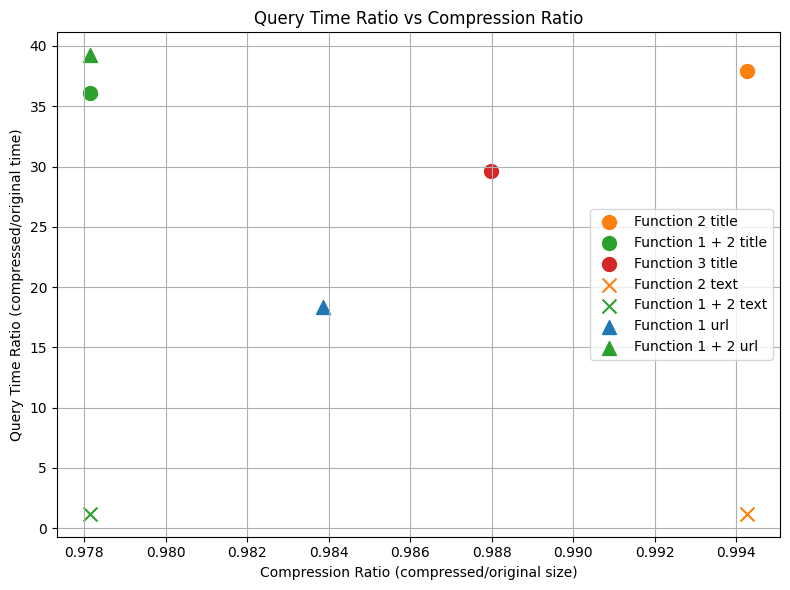

In [17]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
# Create scatter plot of ratios
plt.figure(figsize=(8, 6))
# Plot each point with a label
for i, (cr, qtr) in enumerate(zip(compression_ratios, title_query_time_ratios)):
    if qtr == 0:
        continue  # Skip points with zero query time ratio
    plt.scatter(cr, qtr, label=f"{functions[i]} title", s=100, marker='o', c=colors[i])
for i, (cr, qtr) in enumerate(zip(compression_ratios, text_query_time_ratios)):
    if qtr == 0:
        continue  # Skip points with zero query time ratio
    plt.scatter(cr, qtr, label=f"{functions[i]} text", s=100, marker='x', c=colors[i])
for i, (cr, qtr) in enumerate(zip(compression_ratios, url_query_time_ratios)):
    if qtr == 0:
        continue  # Skip points with zero query time ratio
    plt.scatter(cr, qtr, label=f"{functions[i]} url", s=100, marker='^',c=colors[i])
plt.xlabel("Compression Ratio (compressed/original size)")
plt.ylabel("Query Time Ratio (compressed/original time)")
plt.title("Query Time Ratio vs Compression Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
dataset_id = "HuggingFaceFW/fineweb"
configs_file = "config.json"
compression_methods = ["snappy", "gzip", "brotli", "lz4", "zstd"]
config_dict = json.load(open(configs_file, "r"))[dataset_id]['configs']
compress_methods_count = len(config_dict[0]['compress'])
size_dict = {
    "snappy": 0,
    "gzip": 0,
    "brotli": 0,
    "lz4": 0,
    "zstd": 0,
}
compress_size_list = [size_dict.copy() for _ in range(compress_methods_count)]

In [ ]:
for config in config_dict:
    # print(f"config name: {config['file']}")
    for compression_method in compression_methods:
        size_dict[compression_method] += config[f'size_{compression_method}']
    for i, compress in enumerate(config['compress']):
        for compression_method in compression_methods:
            compress_size_list[i][compression_method] += compress[f'size_compression_{compression_method}']


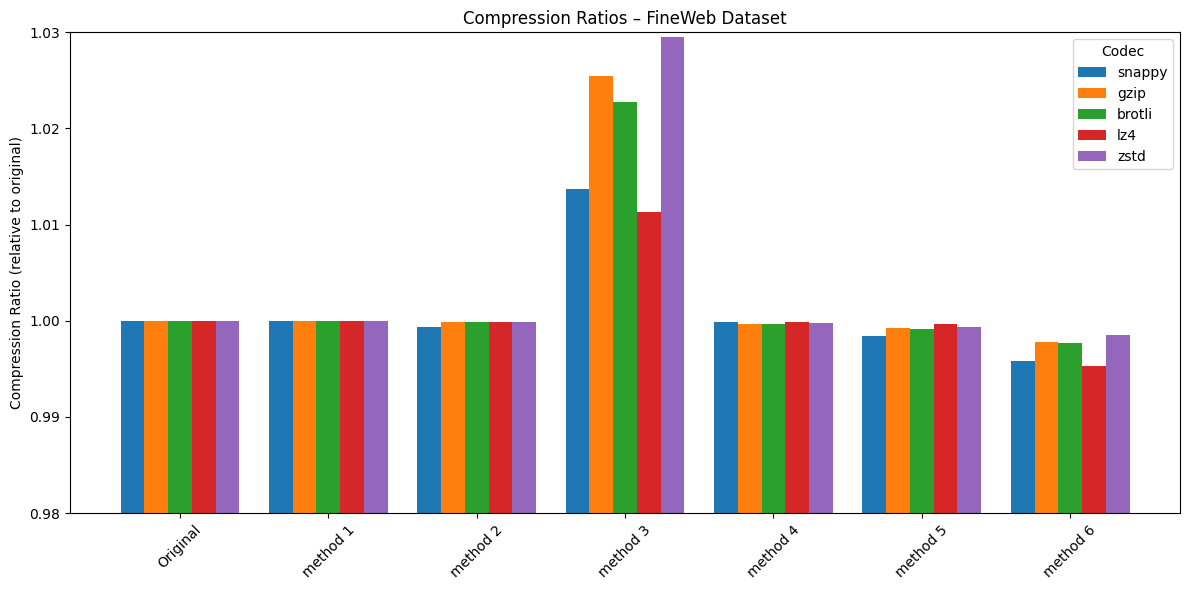

In [ ]:
categories = ["Original", "function 1", "function 2", "function 3", "function 4", "function 5", "function 6"]
# compression_method = "snappy"
values = [size_dict[compression_method]]
# ori = values[0]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

x = np.arange(len(categories))
bar_width = 0.16

plt.figure(figsize=(12, 6))

for idx, method in enumerate(compression_methods):
    vals = [size_dict[method]] + [comp[method] for comp in compress_size_list]
    ori = vals[0]
    ratios = [v / ori for v in vals]
    
    positions = x + (idx - (len(compression_methods) / 2)) * bar_width + bar_width / 2
    plt.bar(positions, ratios, bar_width, label=method, color=colors[idx])

plt.ylabel("Compression Ratio (relative to original)")
plt.title("Compression Ratios – FineWeb Dataset")
plt.xticks(x, categories, rotation=45)
plt.ylim(0.98, 1.03)
plt.legend(title="Codec")
plt.tight_layout()
plt.show()